In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

df = pd.read_csv('ödev1.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [2]:
print("Boyut:", df.shape)
print("\nSütun Bilgileri:")
print(df.info())
print("\nEksik Değerler:")
print(df.isnull().sum())
print("\nSınıf Dağılımı:")
print(df['diagnosis'].value_counts())

Boyut: (569, 33)

Sütun Bilgileri:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    floa

In [3]:
df = df.drop(columns=['id', 'Unnamed: 32'])

In [4]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [5]:
print(df['diagnosis'].value_counts())
print("\nİlk 3 satır:")
df.head(3)

diagnosis
0    357
1    212
Name: count, dtype: int64

İlk 3 satır:


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


In [6]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']
print("X boyutu:", X.shape)
print("y boyutu:", y.shape)  
print("\nX'in ilk 2 satırı:")
print(X.head(2))
print("\ny'nin ilk 5 değeri:")
print(y.head())

X boyutu: (569, 30)
y boyutu: (569,)

X'in ilk 2 satırı:
   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0        17.99         10.38           122.8     1001.0          0.11840   
1        20.57         17.77           132.9     1326.0          0.08474   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   

   fractal_dimension_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0                 0.07871  ...         25.38          17.33            184.6   
1                 0.05667  ...         24.99          23.41            158.8   

   area_worst  smoothness_worst  compactness_worst  concavity_worst  \
0      2019.0            0.1622             0.6656           0.7119   
1      1956.0            0.1238             0.1866           0.2416   

   concave points_worst  symmetry

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      
    random_state=42,    
    stratify=y          
)
print("Eğitim seti boyutu:", X_train.shape)
print("Test seti boyutu  :", X_test.shape)
print("\nEğitim setinde sınıf dağılımı:")
print(y_train.value_counts())
print("\nTest setinde sınıf dağılımı:")
print(y_test.value_counts())

Eğitim seti boyutu: (455, 30)
Test seti boyutu  : (114, 30)

Eğitim setinde sınıf dağılımı:
diagnosis
0    285
1    170
Name: count, dtype: int64

Test setinde sınıf dağılımı:
diagnosis
0    72
1    42
Name: count, dtype: int64


In [8]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("\nEğitim verisinin ilk satırının ilk 5 değeri:")
print(X_train[0, :5])


Eğitim verisinin ilk satırının ilk 5 değeri:
[ 0.51855873  0.89182579  0.4246317   0.38392544 -0.97474371]


In [9]:
model = RandomForestClassifier(
    n_estimators=100,   
    random_state=42     
)
model.fit(X_train, y_train)
print("\nModel kaç ağaçtan oluşuyor:", model.n_estimators)


Model kaç ağaçtan oluşuyor: 100


In [10]:
y_pred = model.predict(X_test)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

Accuracy  : 0.9737
Precision : 1.0000
Recall    : 0.9286
F1-Score  : 0.9630


In [11]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[72  0]
 [ 3 39]]


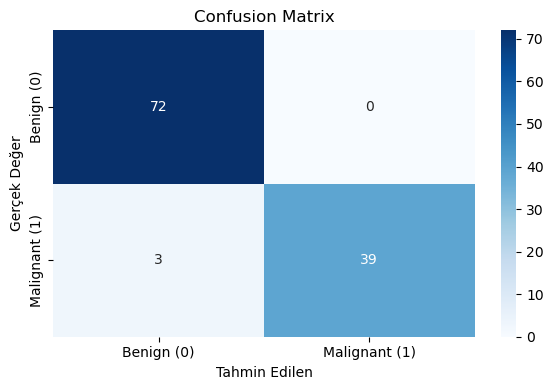

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'])
plt.title('Confusion Matrix')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.tight_layout()
plt.show()

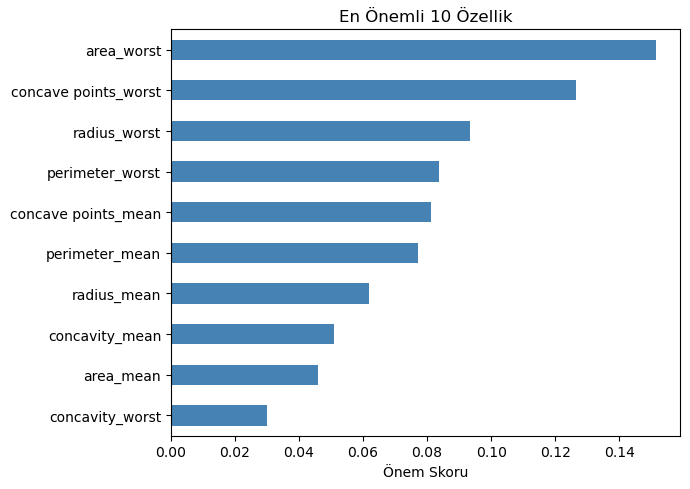

In [13]:
importances = pd.Series(model.feature_importances_, index=X.columns)
top10 = importances.nlargest(10).sort_values()

plt.figure(figsize=(7, 5))
top10.plot(kind='barh', color='steelblue')
plt.title('En Önemli 10 Özellik')
plt.xlabel('Önem Skoru')
plt.tight_layout()
plt.show()

In [14]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

print("Her fold'un skoru:", cv_scores)
print(f"Ortalama       : {cv_scores.mean():.4f}")
print(f"Standart Sapma : {cv_scores.std():.4f}")

Her fold'un skoru: [0.92105263 0.93859649 0.98245614 0.96491228 0.97345133]
Ortalama       : 0.9561
Standart Sapma : 0.0228
